In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.OxfordIIITPet(
    root="./data",
    split="test",
    target_types="category",
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)




cuda


100%|██████████| 792M/792M [00:40<00:00, 19.4MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.06MB/s]


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

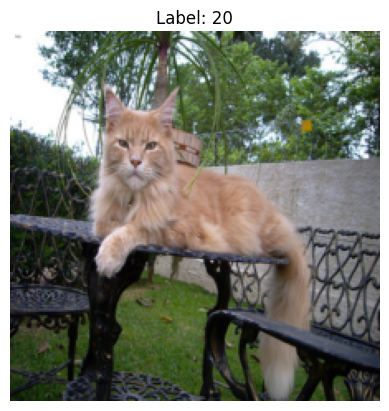

In [ ]:
image, label = train_dataset[1000]

plt.imshow(image.permute(1,2,0))
plt.title(f"Label: {label}")
plt.axis("off")

In [ ]:
from torchvision.models import resnet18

model = resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 37)

model = model.to(device)



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 217MB/s]


In [ ]:
#loss function

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)



In [ ]:
# training

num_epochs = 3
loss_history = []

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        loss_history.append(loss.item())   # <-- ADD THIS LINE HERE

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")



Epoch 1, Loss: 1.5911
Epoch 2, Loss: 0.3689
Epoch 3, Loss: 0.1196


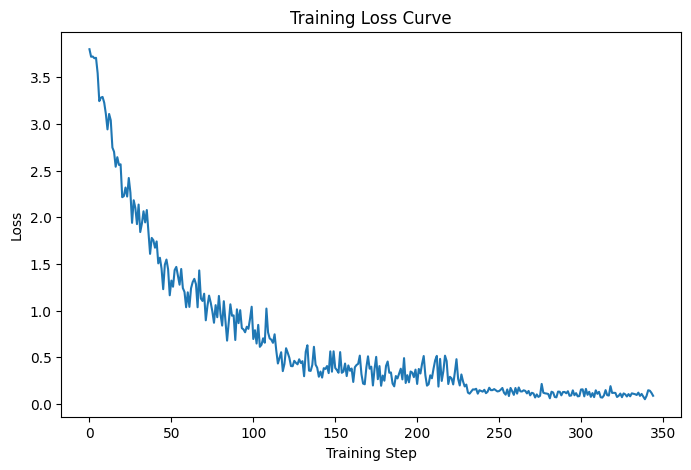

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.show()

In [ ]:
#evaluation

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print("Test Accuracy:", accuracy)

Test Accuracy: 87.51703461433632


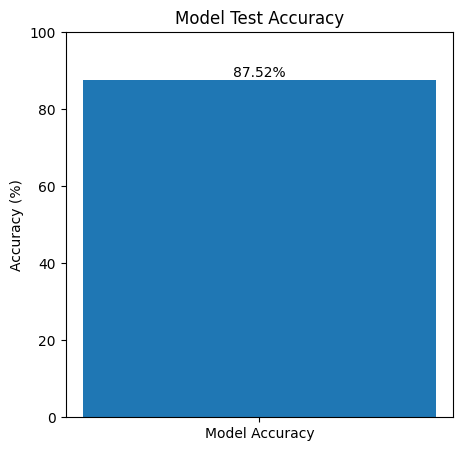

In [ ]:
import matplotlib.pyplot as plt

accuracy_value = accuracy

plt.figure(figsize=(5,5))
plt.bar(["Model Accuracy"], [accuracy_value])
plt.ylim(0,100)

plt.ylabel("Accuracy (%)")
plt.title("Model Test Accuracy")

plt.text(0, accuracy_value + 1, f"{accuracy_value:.2f}%", ha='center')

plt.show()

[[84  0  0 ...  0  0  0]
 [ 0 93  0 ...  1  0  0]
 [ 0 19 40 ... 22  0  0]
 ...
 [ 0 14  6 ... 53  0  0]
 [ 1  0  0 ...  0 90  0]
 [ 0  0  0 ...  0  0 95]]


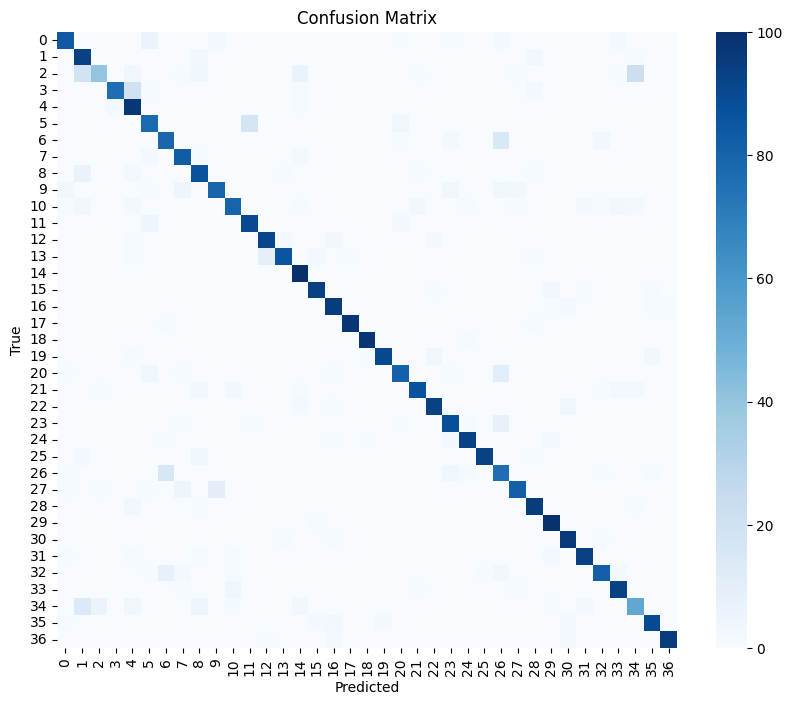

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

print(cm)

import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

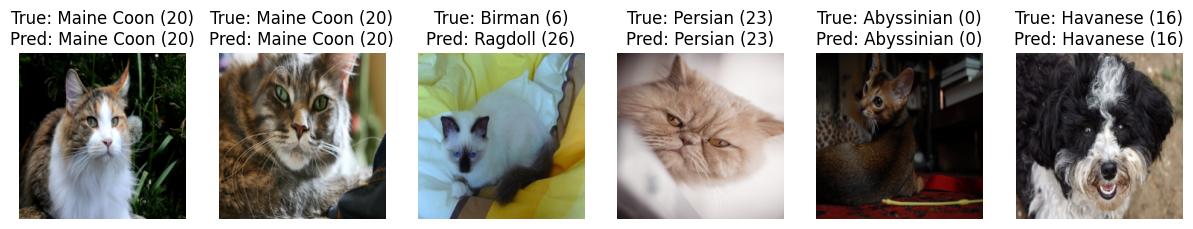

In [ ]:
import random

class_names = train_dataset.classes


model.eval()

num_images = 6
indices = random.sample(range(len(test_dataset)), num_images)

fig, axes = plt.subplots(1, num_images, figsize=(15,5))

for i, idx in enumerate(indices):

    image, label = test_dataset[idx]

    input_img = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)
        _, pred = torch.max(output, 1)

    img = image.permute(1,2,0)

    axes[i].imshow(img)
    axes[i].set_title(
    f"True: {class_names[label]} ({label})\nPred: {class_names[pred.item()]} ({pred.item()})"
)
    axes[i].axis("off")

plt.show()

In [ ]:
# Step 1: Select a random test image

import random

idx = random.randint(0, len(test_dataset)-1)

image, label = test_dataset[idx]

original_image = image.clone().unsqueeze(0).to(device)

print("True label:", label)

True label: 16


In [ ]:
# Step 2: Get model prediction

model.eval()

with torch.no_grad():
    output = model(original_image)
    pred = torch.argmax(output, dim=1)

print("Model prediction:", pred.item())

Model prediction: 16


In [ ]:
# Step 3: Choose target class (Dog ↔ Cat)
import random

target_class = random.choice([i for i in range(37) if i != pred.item()])

print("Target class:", target_class)

Target class: 6


In [ ]:
# Step 11: Reinitialize counterfactual image

cf_image = original_image.clone().detach()
cf_image.requires_grad = True

In [ ]:
# Step 12: Total Variation Loss (for smoothness)

def tv_loss(image):
    loss = torch.sum(torch.abs(image[:, :, :-1] - image[:, :, 1:])) + \
           torch.sum(torch.abs(image[:, :-1, :] - image[:, 1:, :]))
    return loss

In [ ]:
# Step: Blur loss (NEW)

import torch.nn.functional as F

def blur_loss(image):
    kernel = torch.ones((1,1,5,5)).to(image.device) / 25
    kernel = kernel.repeat(3,1,1,1)
    blurred = F.conv2d(image, kernel, padding=2, groups=3)
    return torch.norm(image - blurred)

In [ ]:
# Step 13: Optimizer

optimizer_cf = torch.optim.Adam([cf_image], lr=0.01)

In [ ]:
# Step 14: Improved counterfactual generation

import torch.nn.functional as F

lambda_target = 5
lambda_l1 = 0.03
lambda_tv = 0.02
lambda_blur = 0.01

num_steps = 800

optimizer_cf = torch.optim.Adam([cf_image], lr=0.005)

for step in range(num_steps):

    optimizer_cf.zero_grad()

    output = model(cf_image)

    target = torch.tensor([target_class]).to(device)

    target_loss = F.cross_entropy(output, target)

    l1_loss = torch.norm(cf_image - original_image, p=1)

    smooth_loss = tv_loss(cf_image)

    blur = blur_loss(cf_image)

    loss = (
        lambda_target * target_loss +
        lambda_l1 * l1_loss +
        lambda_tv * smooth_loss +
        lambda_blur * blur
    )

    loss.backward()
    optimizer_cf.step()

    cf_image.data.clamp_(0, 1)

    if step % 100 == 0:
        print(f"Step {step}, Loss: {loss.item():.4f}")

Step 0, Loss: 286.1478
Step 100, Loss: 226.7096
Step 200, Loss: 226.5751
Step 300, Loss: 226.5718
Step 400, Loss: 226.5715
Step 500, Loss: 226.5857
Step 600, Loss: 226.5929
Step 700, Loss: 226.6109


In [ ]:
# Step 15: Check prediction

with torch.no_grad():
    final_output = model(cf_image)
    final_pred = torch.argmax(final_output, dim=1)

print("Final prediction:", final_pred.item())

Final prediction: 6


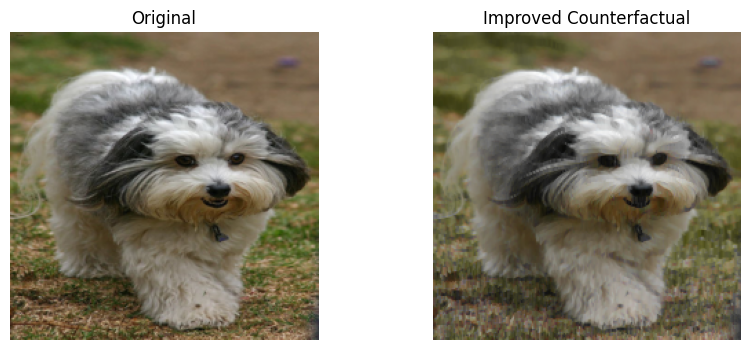

In [ ]:
# Step 16: Show images

orig = original_image.squeeze().cpu().permute(1,2,0)
cf = cf_image.detach().squeeze().cpu().permute(1,2,0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cf)
plt.title("Improved Counterfactual")
plt.axis("off")

plt.show()

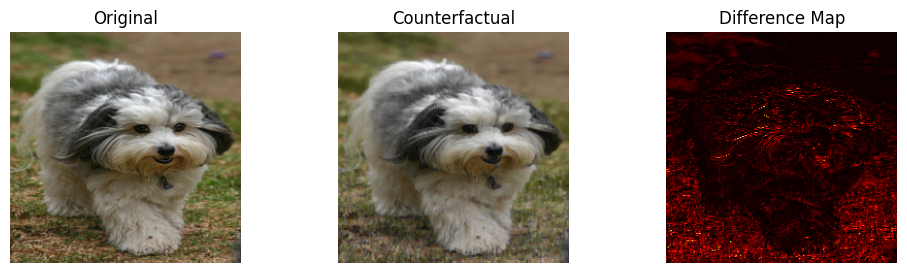

In [ ]:
# show result (UPDATED with diff map)

orig = original_image.squeeze().cpu().permute(1,2,0)
cf = cf_image.detach().squeeze().cpu().permute(1,2,0)

# Difference
diff = torch.abs(cf_image - original_image)
diff = diff.detach().squeeze().cpu().permute(1,2,0)

# Convert to grayscale for clarity
diff_gray = diff.mean(dim=2)

# Normalize
diff_gray = diff_gray / diff_gray.max()

plt.figure(figsize=(12,3))

# Original
plt.subplot(1,3,1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

# Counterfactual
plt.subplot(1,3,2)
plt.imshow(cf)
plt.title("Counterfactual")
plt.axis("off")

# Difference map
plt.subplot(1,3,3)
plt.imshow(diff_gray, cmap='hot')
plt.title("Difference Map")
plt.axis("off")

plt.show()


Sample 1
Original class: 20
Target class: 0


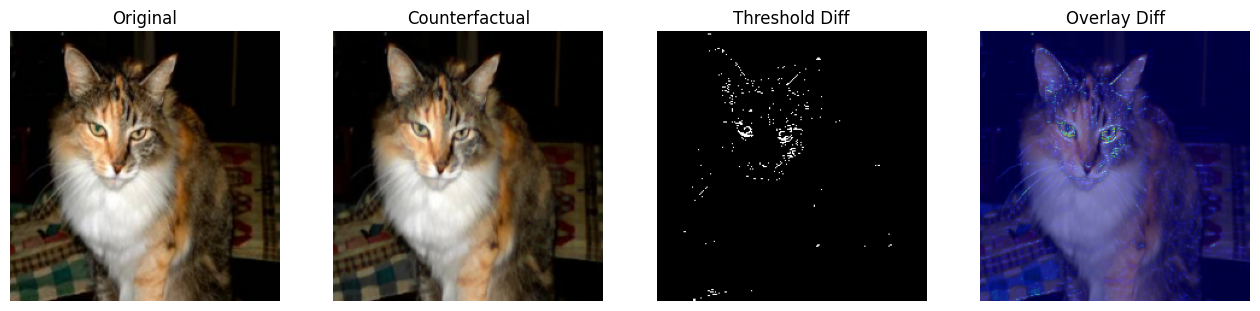


Sample 2
Original class: 19
Target class: 12


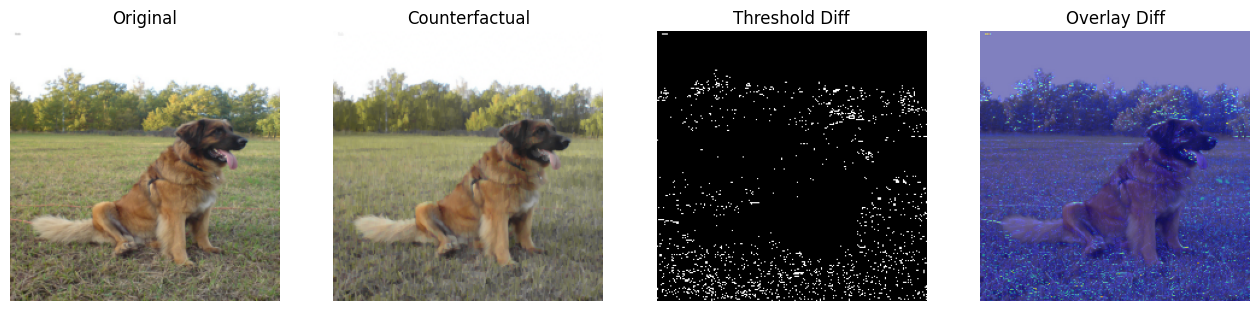


Sample 3
Original class: 21
Target class: 28


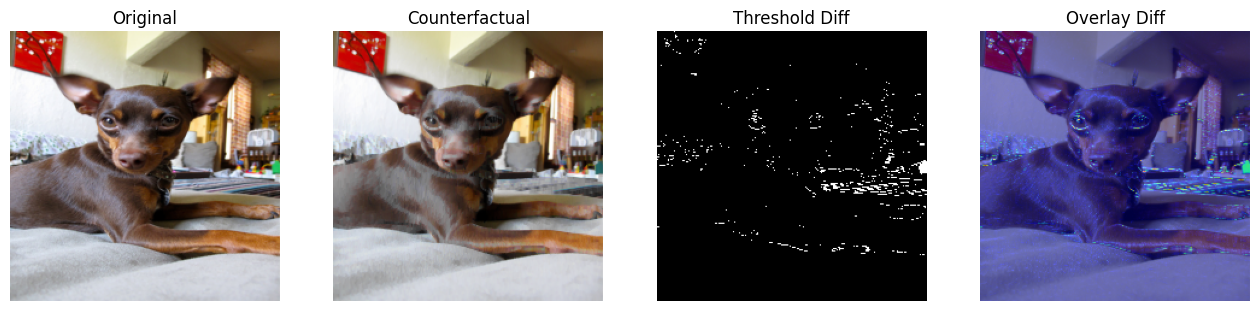


Sample 4
Original class: 31
Target class: 6


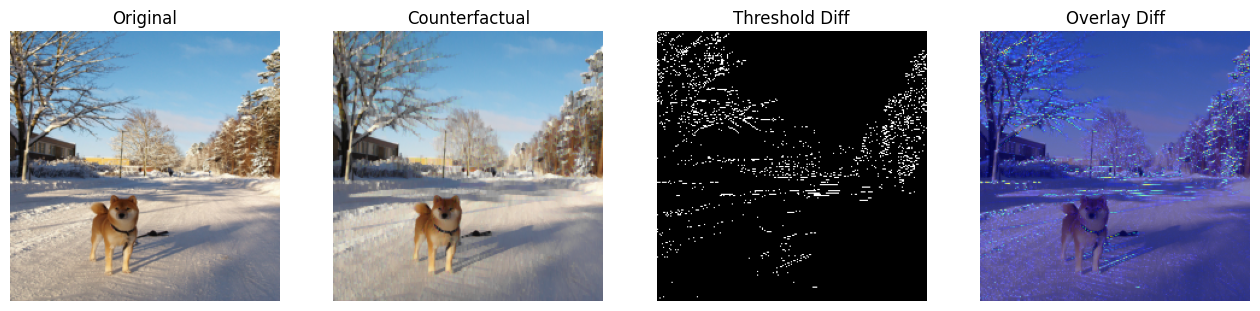


Sample 5
Original class: 10
Target class: 33


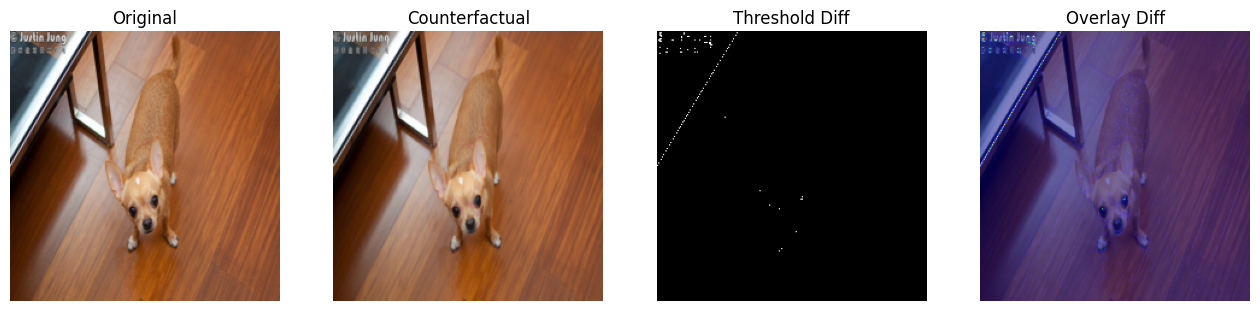

In [ ]:
# FINAL VISUALIZATION CODE (BEST VERSION)

num_samples = 5

for i in range(num_samples):

    idx = random.randint(0, len(test_dataset)-1)
    image, label = test_dataset[idx]

    original_image = image.clone().unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        output = model(original_image)
        pred = torch.argmax(output, dim=1).item()

    # Random target (different class)
    target_class = random.choice([i for i in range(37) if i != pred])

    print(f"\nSample {i+1}")
    print("Original class:", pred)
    print("Target class:", target_class)

    # Initialize counterfactual
    cf_image = original_image.clone().detach()
    cf_image.requires_grad = True

    optimizer_cf = torch.optim.Adam([cf_image], lr=0.005)

    # Optimization loop
    for step in range(300):
        optimizer_cf.zero_grad()

        output = model(cf_image)
        target = torch.tensor([target_class]).to(device)

        target_loss = F.cross_entropy(output, target)
        l1_loss = torch.norm(cf_image - original_image, p=1)
        smooth_loss = tv_loss(cf_image)
        blur = blur_loss(cf_image)

        loss = (
            5 * target_loss +
            0.03 * l1_loss +
            0.02 * smooth_loss +
            0.01 * blur
        )

        loss.backward()
        optimizer_cf.step()
        cf_image.data.clamp_(0, 1)

    # Convert images
    orig = original_image.squeeze().cpu().permute(1,2,0)
    cf = cf_image.detach().squeeze().cpu().permute(1,2,0)

    # Difference map
    diff = torch.abs(cf_image - original_image)
    diff = diff.detach().squeeze().cpu().permute(1,2,0)

    # Grayscale difference
    diff_gray = diff.mean(dim=2)

    # Normalize
    diff_gray = diff_gray / diff_gray.max()

    # Threshold map (clean)
    threshold = 0.2
    diff_thresh = (diff_gray > threshold).float()

    # Plot everything
    plt.figure(figsize=(16,4))

    # Original
    plt.subplot(1,4,1)
    plt.imshow(orig)
    plt.title("Original")
    plt.axis("off")

    # Counterfactual
    plt.subplot(1,4,2)
    plt.imshow(cf)
    plt.title("Counterfactual")
    plt.axis("off")

    # Threshold Difference
    plt.subplot(1,4,3)
    plt.imshow(diff_thresh, cmap='gray')
    plt.title("Threshold Diff")
    plt.axis("off")

    # Overlay (BEST)
    plt.subplot(1,4,4)
    plt.imshow(orig)
    plt.imshow(diff_gray, cmap='jet', alpha=0.5)
    plt.title("Overlay Diff")
    plt.axis("off")

    plt.show()